## Clase 2 - Carga y exploración de datos

### Carga de datos y visualización rápida

#### En esta notebook repasaremos distintas maneras de recolectar datos para luego procesarlos con la biblioteca Pandas. La carga y exploración de datos es la base de cualquier proyecto de Inteligencia Artificial: ningún modelo es mejor que los datos con los que se entrena.

**Qué vamos a ver hoy:**
1. Cargar un CSV (local o remoto)
2. Consumir una API REST
3. Conectarnos a una base de datos con SQL
4. Web scraping básico
5. Primera exploración de un dataset: nulos, duplicados, tipos de datos y visualizaciones

### Librerías que vamos a usar

- `pandas` → manejo de datos tabulares (DataFrames)
- `requests` → hacer pedidos HTTP (APIs, descargar páginas)
- `BeautifulSoup` → parsear HTML para hacer scraping
- `SQLAlchemy` → conectarnos a bases de datos y ejecutar SQL
- `json` / `io.StringIO` → utilidades para convertir texto/JSON a algo que Pandas pueda leer

In [1]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
from sqlalchemy import create_engine, MetaData, text
import json
from io import StringIO

In [2]:
# en Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

#### 1. Cargar datos desde un archivo CSV a un df de Pandas

In [3]:

df_csv = pd.read_csv("https://people.sc.fsu.edu/~jburkardt/data/csv/airtravel.csv")

# Otros formatos comunes: pd.read_parquet, pd.read_json, pd.read_html

In [4]:
# Mostrar las primeras filas (las 5 primeras por defecto)
df_csv.head()  

,Month,"""1958""","""1959""","""1960"""
0,JAN,340,360,417
1,FEB,318,342,391
2,MAR,362,406,419
3,APR,348,396,461
4,MAY,363,420,472


In [ ]:
df_csv.tail(6) # Mostrar las últimas 6 filas

,Month,"""1958""","""1959""","""1960"""
7,AUG,505,559,606
8,SEP,404,463,508
9,OCT,359,407,461
10,NOV,310,362,390
11,DEC,337,405,432


> 💡 **En vivo:** probemos cambiar la URL de `pd.read_csv` por otro CSV público (o uno propio) y repetir `.head()` / `.tail()`.

#### 2. Recolectar datos a través de una API

Una API expone datos en un formato estándar (generalmente JSON) a través de pedidos HTTP. Antes de usar la respuesta conviene chequear siempre el `status_code`: `200` significa que salió todo bien.

La API del SMN es pública y a veces está caída o saturada (nos pasó en clase). Por eso la celda de abajo tiene un **respaldo**: si el SMN no responde `200`, prueba automáticamente con otra API que devuelve datos con una forma similar (una lista de objetos, cada uno con un campo anidado).

In [12]:
# Ejemplo: API del SMN Argentino (con respaldo si no responde)

url_smn = "https://ws.smn.gob.ar/map_items/forecast/1"  # Forecast de 1 día
url_respaldo = "https://jsonplaceholder.typicode.com/users"  # Misma forma: lista de objetos con un campo anidado

response_smn = requests.get(url_smn)

if response_smn.status_code == 200:
    data_smn = response_smn.json()
    print("Se obtuvo respuesta del SMN!")

else:
    print(f"El SMN no respondió (status {response_smn.status_code}), usamos la API de respaldo")
    response_smn = requests.get(url_respaldo)
    data_smn = response_smn.json()

El SMN no respondió (status 503), usamos la API de respaldo


In [13]:
data_smn[:2]

[{'id': 1,
  'name': 'Leanne Graham',
  'username': 'Bret',
  'email': 'Sincere@april.biz',
  'address': {'street': 'Kulas Light',
   'suite': 'Apt. 556',
   'city': 'Gwenborough',
   'zipcode': '92998-3874',
   'geo': {'lat': '-37.3159', 'lng': '81.1496'}},
  'phone': '1-770-736-8031 x56442',
  'website': 'hildegard.org',
  'company': {'name': 'Romaguera-Crona',
   'catchPhrase': 'Multi-layered client-server neural-net',
   'bs': 'harness real-time e-markets'}},
 {'id': 2,
  'name': 'Ervin Howell',
  'username': 'Antonette',
  'email': 'Shanna@melissa.tv',
  'address': {'street': 'Victor Plains',
   'suite': 'Suite 879',
   'city': 'Wisokyburgh',
   'zipcode': '90566-7771',
   'geo': {'lat': '-43.9509', 'lng': '-34.4618'}},
  'phone': '010-692-6593 x09125',
  'website': 'anastasia.net',
  'company': {'name': 'Deckow-Crist',
   'catchPhrase': 'Proactive didactic contingency',
   'bs': 'synergize scalable supply-chains'}}]

In [14]:
# Primera forma 

df_api_1 = pd.DataFrame(data_smn)

df_api_1.head()

,id,name,username,email,address,phone,website,company
0,1,Leanne Graham,Bret,Sincere@april.biz,"{'street': 'Kulas Light', 'suite': 'Apt. 556',...",1-770-736-8031 x56442,hildegard.org,"{'name': 'Romaguera-Crona', 'catchPhrase': 'Mu..."
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,"{'street': 'Victor Plains', 'suite': 'Suite 87...",010-692-6593 x09125,anastasia.net,"{'name': 'Deckow-Crist', 'catchPhrase': 'Proac..."
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,"{'street': 'Douglas Extension', 'suite': 'Suit...",1-463-123-4447,ramiro.info,"{'name': 'Romaguera-Jacobson', 'catchPhrase': ..."
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,"{'street': 'Hoeger Mall', 'suite': 'Apt. 692',...",493-170-9623 x156,kale.biz,"{'name': 'Robel-Corkery', 'catchPhrase': 'Mult..."
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,"{'street': 'Skiles Walks', 'suite': 'Suite 351...",(254)954-1289,demarco.info,"{'name': 'Keebler LLC', 'catchPhrase': 'User-c..."


In [15]:
# Segunda forma 

df_api_2 = pd.json_normalize(data_smn) # Desarma los diccionarios anidados

df_api_2.head()

,id,name,username,email,phone,website,address.street,address.suite,address.city,address.zipcode,address.geo.lat,address.geo.lng,company.name,company.catchPhrase,company.bs
0,1,Leanne Graham,Bret,Sincere@april.biz,1-770-736-8031 x56442,hildegard.org,Kulas Light,Apt. 556,Gwenborough,92998-3874,-37.3159,81.1496,Romaguera-Crona,Multi-layered client-server neural-net,harness real-time e-markets
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,010-692-6593 x09125,anastasia.net,Victor Plains,Suite 879,Wisokyburgh,90566-7771,-43.9509,-34.4618,Deckow-Crist,Proactive didactic contingency,synergize scalable supply-chains
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,1-463-123-4447,ramiro.info,Douglas Extension,Suite 847,McKenziehaven,59590-4157,-68.6102,-47.0653,Romaguera-Jacobson,Face to face bifurcated interface,e-enable strategic applications
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,493-170-9623 x156,kale.biz,Hoeger Mall,Apt. 692,South Elvis,53919-4257,29.4572,-164.2990,Robel-Corkery,Multi-tiered zero tolerance productivity,transition cutting-edge web services
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,(254)954-1289,demarco.info,Skiles Walks,Suite 351,Roscoeview,33263,-31.8129,62.5342,Keebler LLC,User-centric fault-tolerant solution,revolutionize end-to-end systems


In [16]:
# Tercera forma

json_str = json.dumps(data_smn) # Convierte data_smn que es una lista
json_str_io = StringIO(json_str) # StringIO es el tipo de entrada que espera pd.read_json
df_api_3 = pd.read_json(json_str_io)

df_api_3.head()


,id,name,username,email,address,phone,website,company
0,1,Leanne Graham,Bret,Sincere@april.biz,"{'street': 'Kulas Light', 'suite': 'Apt. 556',...",1-770-736-8031 x56442,hildegard.org,"{'name': 'Romaguera-Crona', 'catchPhrase': 'Mu..."
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,"{'street': 'Victor Plains', 'suite': 'Suite 87...",010-692-6593 x09125,anastasia.net,"{'name': 'Deckow-Crist', 'catchPhrase': 'Proac..."
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,"{'street': 'Douglas Extension', 'suite': 'Suit...",1-463-123-4447,ramiro.info,"{'name': 'Romaguera-Jacobson', 'catchPhrase': ..."
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,"{'street': 'Hoeger Mall', 'suite': 'Apt. 692',...",493-170-9623 x156,kale.biz,"{'name': 'Robel-Corkery', 'catchPhrase': 'Mult..."
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,"{'street': 'Skiles Walks', 'suite': 'Suite 351...",(254)954-1289,demarco.info,"{'name': 'Keebler LLC', 'catchPhrase': 'User-c..."


**¿Cuál de las 3 formas usar?**
- `pd.DataFrame(data)` → rápido, pero deja el campo anidado (`weather` en el SMN, `address` en la API de respaldo) como un diccionario sin desarmar.
- `pd.json_normalize(data)` → la más usada en la práctica: aplana automáticamente los diccionarios anidados en columnas (por ejemplo `weather.morning_temp` o `address.geo.lat`).
- `pd.read_json(...)` → útil cuando ya tenés el JSON como texto/archivo, no como objeto en memoria.

#### 3. Conectarse a una base de datos

`SQLAlchemy` nos da un `engine`: la conexión a la base. Con `MetaData().reflect()` le pedimos que **descubra solo** las tablas y columnas existentes, sin tener que conocerlas de antemano.

In [17]:
DATABASE_URL = "sqlite:///../datasets/movie.sqlite"  # Path al archivo sqlite
engine = create_engine(DATABASE_URL)

# Obtener datos de las tablas
metadata = MetaData()
metadata.reflect(bind=engine)

print(f"Tablas disponibles en la DB:{list(metadata.tables.keys())}")


Tablas disponibles en la DB:['IMDB', 'earning', 'genre']


In [18]:
tabla_imdb = metadata.tables['IMDB'] # Tabla IMDB
print(f"Columnas disponibles en la tabla IMDB:{list(tabla_imdb.columns.keys())}")

Columnas disponibles en la tabla IMDB:['Movie_id', 'Title', 'Rating', 'TotalVotes', 'MetaCritic', 'Budget', 'Runtime', 'CVotes10', 'CVotes09', 'CVotes08', 'CVotes07', 'CVotes06', 'CVotes05', 'CVotes04', 'CVotes03', 'CVotes02', 'CVotes01', 'CVotesMale', 'CVotesFemale', 'CVotesU18', 'CVotesU18M', 'CVotesU18F', 'CVotes1829', 'CVotes1829M', 'CVotes1829F', 'CVotes3044', 'CVotes3044M', 'CVotes3044F', 'CVotes45A', 'CVotes45AM', 'CVotes45AF', 'CVotes1000', 'CVotesUS', 'CVotesnUS', 'VotesM', 'VotesF', 'VotesU18', 'VotesU18M', 'VotesU18F', 'Votes1829', 'Votes1829M', 'Votes1829F', 'Votes3044', 'Votes3044M', 'Votes3044F', 'Votes45A', 'Votes45AM', 'Votes45AF', 'VotesIMDB', 'Votes1000', 'VotesUS', 'VotesnUS']


In [23]:
# Ejemplo: creamos la query a la tabla IMDB (buscamos las películas con rating >= 7)
query_imdb = text("""
    SELECT Movie_id, Title, Rating, TotalVotes
    FROM IMDB
    WHERE Rating >= 7
""")


# Creamos la conexión
with engine.connect() as connection:
    # Cargamos el resultado de la query en un df de Pandas
    df_sql_imdb = pd.read_sql(query_imdb, connection)

# Display the first few rows
df_sql_imdb.head()

,Movie_id,Title,Rating,TotalVotes
0,36809,12 Years a Slave (2013),8.1,496092
1,30114,127 Hours (2010),7.6,297075
2,37367,50/50 (2011),7.7,283935
3,49473,About Time (2013),7.8,225412
4,14867,Amour (2012),7.9,76121


> 💡 **En vivo:** cambiemos el `WHERE Rating >= 7` de la query por otro umbral, o agreguemos una columna más al `SELECT`.

#### 4. Web scraping

#### Atención: 

En este ejemplo utilizamos una web que está pensada para uso educativo. En un caso real, **SIEMPRE** antes de hacer scraping hay que:
* Revisar términos y condiciones de uso del sitio web.
* Revisar el archivo `robots.txt` del sitio web (ejemplo `https://wikipedia.com/robots.txt`) que contiene las recomendaciones del desarrollador.
* Solicitar permiso al dueño del sitio.

In [24]:
# URL para hacer el scraping (títulos de libros)
url = "http://books.toscrape.com/"

# Traer el HTML
response = requests.get(url)

##--------Ejemplo simplificado del HTML-------------##
# <article class="product_pod">
#     <h3><a href="catalogue/some-book_1/index.html">Book Title</a></h3>
#     <p class="price_color">£10.99</p>
#     <p class="star-rating Three">★★★☆☆</p>
# </article>


if response.status_code == 200:
    
    # Parsear el HTML
    soup = BeautifulSoup(response.text, "html.parser") # Permite encontrar los elementos a partir de los tags
    
    # Inicializar listas para guardar los datos
    titulos = []
    precios = []
    ratings = []
    
    # Encontrar todos los artículos
    books = soup.select("article.product_pod")
    
    for book in books:
        # Extraer título
        titulo = book.select_one("h3 a").text.strip()
        titulos.append(titulo)
        
        # Extraer precio
        precio = book.select_one(".price_color").text.strip()
        precios.append(precio)
        
        # Extraer el rating
        rating_elem = book.select_one(".star-rating")
        rating = rating_elem["class"][1] 
        ratings.append(rating)
    
else:
    print(f"No se pudo capturar el HTML (Error: {response.status_code})")

In [25]:
# Crear un Pandas DataFrame a partir de las 3 listas resultantes del scraping
df_web = pd.DataFrame({
    "Titulos": titulos,
    "Precios": precios,
    "Ratings": ratings
})

df_web.head() 

,Titulos,Precios,Ratings
0,A Light in the ...,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History ...,Â£54.23,Five


> Esto es scraping "manual": funciona porque conocemos de antemano la estructura del HTML. Si la página cambia su diseño, el scraper se rompe — por eso, cuando existe una API oficial, siempre es preferible usarla en vez de hacer scraping.

### Introducción al análisis más detallado

Una vez que tenemos los datos cargados, antes de graficar o entrenar cualquier modelo hay que **entenderlos**: ¿faltan valores?, ¿hay filas repetidas?, ¿los tipos de datos son los correctos? Esta primera exploración evita sorpresas más adelante.

1. Ejemplo con dataset "turismo.csv"

In [26]:
path="../datasets/turismo.csv"

df = pd.read_csv(path)

df.head()

,indice_tiempo,turismo_receptivo,turismo_emisivo,saldo
0,2010-01-01,254.157,162.680,91.477
1,2010-02-01,186.441,186.227,0.214
2,2010-03-01,203.821,167.262,36.559
3,2010-04-01,207.516,141.750,65.766
4,2010-05-01,191.665,154.430,37.235


Un buen primer paso es pedirle a Pandas un resumen general del DataFrame:

In [27]:
df.info()  # Tipos de datos, nulos y uso de memoria de un vistazo

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   indice_tiempo      180 non-null    str    
 1   turismo_receptivo  180 non-null    float64
 2   turismo_emisivo    180 non-null    float64
 3   saldo              180 non-null    float64
dtypes: float64(3), str(1)
memory usage: 5.8 KB


2. Revisar datos faltantes y duplicados

In [28]:
print(f"Valores faltantes: {df.isnull().sum()}")  # Calcular valores faltantes


Valores faltantes: indice_tiempo        0
turismo_receptivo    0
turismo_emisivo      0
saldo                0
dtype: int64


In [29]:
print("Cantidad de datos duplicados:", df.duplicated().sum())

Cantidad de datos duplicados: 0


In [30]:
print(f"Columnas del dataframe:\n{df.dtypes}\n")

Columnas del dataframe:
indice_tiempo            str
turismo_receptivo    float64
turismo_emisivo      float64
saldo                float64
dtype: object



También conviene mirar un resumen estadístico rápido de las columnas numéricas:

In [31]:
df.describe()  # Media, desvío, mínimo, máximo y cuartiles de las columnas numéricas

,turismo_receptivo,turismo_emisivo,saldo
count,180.000000,180.000000,180.000000
mean,179.101444,207.083733,-27.982289
std,70.666200,84.436787,61.842816
min,0.000000,0.000000,-213.000000
25%,171.450000,171.069000,-72.175000
50%,196.763500,218.345000,-22.127500
75%,221.315250,264.718000,13.979750
max,307.928000,390.800000,108.047000


3. Inspeccionar y corregir tipos de datos

In [32]:
df["indice_tiempo"] = pd.to_datetime(df["indice_tiempo"])
df.dtypes

indice_tiempo        datetime64[us]
turismo_receptivo           float64
turismo_emisivo             float64
saldo                       float64
dtype: object

#### alternativamente:

In [33]:
df = pd.read_csv(path, parse_dates = ['indice_tiempo'])
df.dtypes

indice_tiempo        datetime64[us]
turismo_receptivo           float64
turismo_emisivo             float64
saldo                       float64
dtype: object

4. Creación de nuevas columnas

Extraer año y mes de una fecha es un ejemplo simple de **feature engineering**: crear nuevas variables a partir de las que ya tenemos, para facilitar el análisis o el modelado.

In [34]:
df["año"] = df["indice_tiempo"].dt.year
df["mes"] = df["indice_tiempo"].dt.month
df.head()

,indice_tiempo,turismo_receptivo,turismo_emisivo,saldo,año,mes
0,2010-01-01,254.157,162.680,91.477,2010,1
1,2010-02-01,186.441,186.227,0.214,2010,2
2,2010-03-01,203.821,167.262,36.559,2010,3
3,2010-04-01,207.516,141.750,65.766,2010,4
4,2010-05-01,191.665,154.430,37.235,2010,5


### Algunas visualizaciones

Una visualización rápida ayuda a detectar tendencias, estacionalidad o valores atípicos que son difíciles de ver solo mirando la tabla.

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

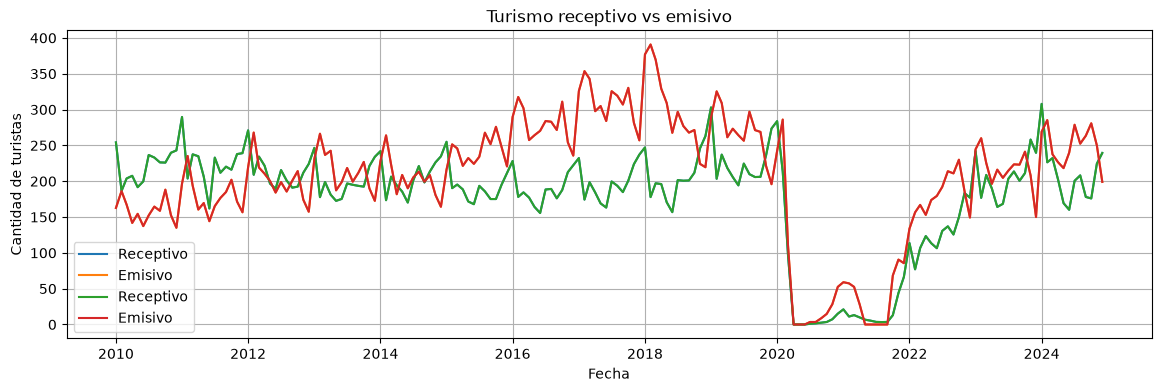

In [ ]:
# Turismo receptivo vs emisivo
plt.figure(figsize=(14, 4))

plt.plot(df["indice_tiempo"], df["turismo_receptivo"], label="Receptivo")
plt.plot(df["indice_tiempo"], df["turismo_emisivo"], label="Emisivo")

# Con Seaborn
#sns.lineplot(data=df, x="indice_tiempo", y="turismo_receptivo", label="Receptivo")
#sns.lineplot(data=df, x="indice_tiempo", y="turismo_emisivo", label="Emisivo")

# Títulos y etiquetas
plt.title("Turismo receptivo vs emisivo")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de turistas")
plt.legend()
plt.grid(True)

plt.show()


**La banda sombreada alrededor de cada línea** es el *intervalo de confianza* que dibuja `sns.lineplot` automáticamente (no es algo que pidamos nosotros).

Como hay 12 filas por año (una por mes), seaborn agrupa por `año` y:
1. Calcula el **promedio** de esos 12 meses → eso es la línea.
2. Calcula un **intervalo de confianza del 95%** con la variación entre esos meses → eso es la banda. Una banda angosta significa que los meses de ese año fueron parecidos entre sí; una banda ancha, que hubo mucha diferencia estacional.

Es exclusivo de seaborn (con `matplotlib` puro no aparece solo). Se puede sacar o cambiar con el parámetro `errorbar`: `errorbar=None` (sin banda), `errorbar="sd"` (desvío estándar en vez de intervalo de confianza).

In [ ]:
# Turismo receptivo vs emisivo - media mensual
plt.figure(figsize=(14, 4))
sns.lineplot(data=df, x="año", y="turismo_receptivo", label="Receptivo")
sns.lineplot(data=df, x="año", y="turismo_emisivo", label="Emisivo")

# Títulos y etiquetas
plt.title("Evolución del Turismo receptivo - Media anual")
plt.xlabel("Año")
plt.ylabel("Promedio de Turismo Receptivo")
plt.grid(True)
plt.show()


## Resumen de la clase

- Un mismo objetivo (tener datos en un DataFrame) se puede lograr desde varias fuentes: CSV, API, base de datos, scraping.
- Antes de usar los datos para lo que sea (gráficos, modelos de ML) hay que explorarlos: `.info()`, `.isnull()`, `.duplicated()`, `.dtypes`, `.describe()`.
- Los tipos de datos importan: una fecha guardada como texto (`object`) no se puede graficar ni ordenar cronológicamente como uno espera.
- Crear columnas derivadas (feature engineering) es habitual antes de analizar o entrenar un modelo.